# Inside the `.embeddings.zarr` store (and its FAIR provenance)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CraigMyles/raw2features/blob/main/notebooks/03_the_embeddings_store.ipynb)

raw2features writes one self-describing **`.embeddings.zarr`** per slide. This notebook
opens one up and *shows* its parts: the patch grid, the tissue mask, the feature matrix,
how every vector relocates onto the slide, and the provenance that makes the result
reproducible. Offline - synthetic slide, no token, no GPU. The format is specified in
[`SPEC.md`](../docs/SPEC.md).

In [1]:
# Bootstrap: works on Colab and a local install.
import importlib.util, subprocess, sys

IN_COLAB = "google.colab" in sys.modules
HAVE_PKG = importlib.util.find_spec("raw2features") is not None
EXTRAS = "zarr,image,torch,models"
SPEC = f"raw2features[{EXTRAS}]"  # PyPI; pin a version (==0.1.1) for reproducibility
if IN_COLAB or not HAVE_PKG:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", SPEC])

import os, tempfile
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import raw2features
from raw2features.core.geometry import Point, Region, Size
from raw2features.readers.omezarr import OmeZarrReader

mpl.rcParams["figure.dpi"] = 72
WORK = tempfile.mkdtemp(prefix="r2f_store_")
print("raw2features", raw2features.__version__)

raw2features 0.1.0


## 1. Produce a store

A synthetic slide → embeddings, so the rest of the notebook has something real to open.

In [2]:
SLIDE = os.path.join(WORK, "sample.ome.zarr")
OUT = os.path.join(WORK, "out")
MODEL, MPP, PATCH = "resnet50", 0.5, 224
subprocess.check_call(["raw2features", "sample", SLIDE, "--size", "3072"])
subprocess.check_call(["raw2features", "embed", SLIDE, OUT + "/",
                       "-m", MODEL, "--mpp", str(MPP), "--device", "cpu"])
STORE = os.path.join(OUT, "sample.embeddings.zarr")
print("store:", STORE)

wrote synthetic OME-Zarr slide: /tmp/r2f_store_x1wi3yab/sample.ome.zarr
try:  raw2features embed /tmp/r2f_store_x1wi3yab/sample.ome.zarr out/ -m resnet50 --device auto


slide_id: sample
status: complete
grids: {'mpp0.5_px224': ['resnet50']}
output_uri: file:///tmp/r2f_store_x1wi3yab/out/sample.embeddings.zarr
per_grid: [{'slide_id': 'sample', 'status': 'complete', 'n_patches': 90, 'models': ['resnet50'], 'models_added': ['resnet50'], 'models_skipped': [], 'slide_embeddings': {}, 'output_uri': 'file:///tmp/r2f_store_x1wi3yab/out/sample.embeddings.zarr', 'geojson': None, 'thumbnail': None, 'elapsed_s': 3.22}]
elapsed_s: 3.75


store: /tmp/r2f_store_x1wi3yab/out/sample.embeddings.zarr


## 2. What's in the box

A `.embeddings.zarr` is a plain Zarr group. The required parts are `coords` (where each
patch is) and `features/<model>` (the vectors); `grid_index` and `mask` describe the grid.
Any Zarr reader can open it - no raw2features needed.

In [3]:
from raw2features.core.store import open_grid  # selects the single grid (grids/<mpp>_<px>/)
g = open_grid(STORE)

def show_tree(grp, prefix=""):
    for k in sorted(grp.array_keys()):
        a = grp[k]
        print(f"{prefix}{k:<14} {str(tuple(a.shape)):<14} {a.dtype}")
    for k in sorted(grp.group_keys()):
        print(f"{prefix}{k}/")
        show_tree(grp[k], prefix + "  ")

show_tree(g)

coords = g["coords"][:]
feats = g["features"][MODEL][:].astype(np.float32)
mask = g["mask"][:] if "mask" in g else None
level0_patch = int(g.attrs["raw2features"]["patching"]["level0_patch"])

coords         (90, 2)        int32
grid_index     (90, 2)        int32
mask           (13, 13)       uint8
features/
  resnet50       (90, 2048)     float16


Now *look* at the three parts. The **tissue mask** is the Otsu **segmentation** (the
fraction of each grid cell that is tissue) - *not* the optional GrandQC QC layer. The
**feature matrix** is the raw `(N patches x dim)` embeddings - the data itself, not meant
to be read by eye. The **coords** place each patch at its level-0 pixel footprint, tiling
the tissue as a regular grid. (The synthetic slide is deliberately simple, so these show
the store's *shape*, not biology.)

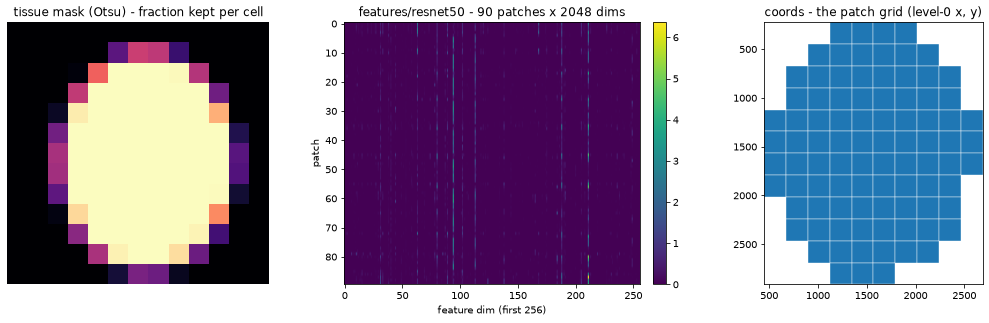

In [4]:
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# 1. tissue mask: Otsu segmentation, the fraction of each grid cell that is tissue
if mask is not None:
    axes[0].imshow(mask, cmap="magma")
axes[0].set_title("tissue mask (Otsu) - fraction kept per cell"); axes[0].axis("off")

# 2. the feature matrix itself: one row per patch (first 256 of 2048 dims)
im = axes[1].imshow(feats[:, :256], aspect="auto", cmap="viridis")
axes[1].set_title(f"features/{MODEL} - {feats.shape[0]} patches x {feats.shape[1]} dims")
axes[1].set_xlabel("feature dim (first 256)"); axes[1].set_ylabel("patch")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# 3. coords: each patch's level-0 footprint at its true position (a regular grid)
cells = [Rectangle((x, y), level0_patch, level0_patch) for x, y in coords]
axes[2].add_collection(PatchCollection(cells, facecolor="tab:blue", edgecolor="white", lw=0.4))
axes[2].set_xlim(coords[:, 0].min(), coords[:, 0].max() + level0_patch)
axes[2].set_ylim(coords[:, 1].max() + level0_patch, coords[:, 1].min())  # y grows downward
axes[2].set_aspect("equal")
axes[2].set_title("coords - the patch grid (level-0 x, y)")
plt.tight_layout(); plt.show()

## 3. Every vector relocates onto the slide

`coords[i]` is the level-0 pixel position of patch `i`, and row `i` of every `features`
array is that patch's embedding - a strict **1:1** correspondence. So a feature vector is
anchored: it places back exactly onto the source slide. Here we colour each patch by
its features (PCA→RGB) and drop it onto the slide thumbnail.

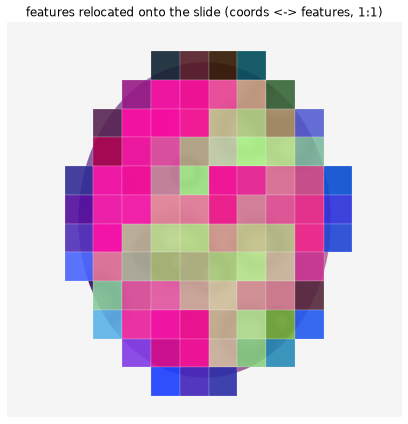

In [5]:
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle

with OmeZarrReader(SLIDE) as r:
    lvl = len(r.level_dimensions) - 1
    sw, sh = r.level_dimensions[lvl]
    thumb = r.read_region(Region(level=lvl, location=Point(0, 0), size=Size(sw, sh)))
    ds = r.level_downsamples()[lvl]

X = feats - feats.mean(0)
_, _, Vt = np.linalg.svd(X, full_matrices=False)
pc = X @ Vt[:3].T
rgb = (pc - pc.min(0)) / (np.ptp(pc, axis=0) + 1e-9)

assert coords.shape[0] == feats.shape[0]            # the 1:1 invariant, in one line
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(thumb, extent=[0, sw * ds, sh * ds, 0])   # the slide thumbnail, in level-0 coords
# each patch at its true level-0 footprint, coloured by its features (PCA -> RGB)
cells = [Rectangle((x, y), level0_patch, level0_patch) for x, y in coords]
ax.add_collection(PatchCollection(cells, facecolors=rgb, edgecolor="white", lw=0.2, alpha=0.9))
ax.set_xlim(0, sw * ds); ax.set_ylim(sh * ds, 0)
ax.set_title("features relocated onto the slide (coords <-> features, 1:1)")
ax.axis("off"); plt.tight_layout(); plt.show()

## 4. Provenance you can trust

The header records everything needed to reproduce and trust the result: the source slide,
the exact grid geometry, and - per model - the **pinned weights** (an immutable Hugging
Face revision, plus a sha256), the preprocessing, licence and DOI. (ResNet-50's weights
are torchvision-managed, so they pin via an immutable weights *enum* and the sha256 is
`null` - see [`SPEC.md`](../docs/SPEC.md).)

In [6]:
hdr = g.attrs["raw2features"]
src, pat, prov = hdr["source"], hdr["patching"], hdr["provenance"]
m = hdr["models"][MODEL]

print(f"schema_version : {hdr['schema_version']}")
print(f"source         : {src['slide_id']}  ({src['ngff_version']}, {src['mpp_level0']} µm/px)")
print(f"patching       : {pat['n_patches']} patches @ {pat['achieved_mpp']} µm/px, "
      f"{pat['patch_px']}px  (grid {pat['grid_shape']})")
print(f"\nmodel  {MODEL}")
print(f"  embedding_dim    : {m['embedding_dim']}")
print(f"  license / doi    : {m['license']}  |  {m['doi']}")
print(f"  weights_revision : {m['weights_revision']}")
print(f"  weights_sha256   : {m['weights_sha256']}")
print(f"\nprovenance")
print(f"  raw2features     : {prov['raw2features_version']}   git: {prov.get('git_sha')}")
print(f"  created_utc      : {prov['created_utc']}")
print(f"  python / platform: {prov['python']}  |  {prov['platform']}")

schema_version : 0.1
source         : sample  (0.4, 0.5 µm/px)
patching       : 90 patches @ 0.5 µm/px, 224px  (grid [13, 13])

model  resnet50
  embedding_dim    : 2048
  license / doi    : BSD-3-Clause (torchvision)  |  10.1109/CVPR.2016.90
  weights_revision : IMAGENET1K_V2
  weights_sha256   : None

provenance
  raw2features     : 0.1.0   git: 31f2c0eb0df205b64aed2cc892f364e5c80a89cd
  created_utc      : 2026-06-30T16:57:37Z
  python / platform: 3.12.3  |  Linux-x86_64


## 5. It conforms to the spec

`validate-store` checks the store against [`SPEC.md`](../docs/SPEC.md) - required arrays, the
1:1 invariant, array roles/units, and the full per-model provenance. It runs on a local
path or a remote URL, with only a Zarr library.

In [7]:
subprocess.run(["raw2features", "validate-store", STORE], check=True)

OK - conforms to embeddings-store spec v0.1


CompletedProcess(args=['raw2features', 'validate-store', '/tmp/r2f_store_x1wi3yab/out/sample.embeddings.zarr'], returncode=0)

## Takeaway

One slide in, one self-describing store out: vectors that relocate onto the slide, a
machine-readable header, pinned weights, and spec conformance. That's what makes the output
**FAIR** - findable, accessible, interoperable, reusable. Feed it onward with
[`04_spatialdata.ipynb`](04_spatialdata.ipynb), or revisit the real-slide tour in
[`02_visual_walkthrough.ipynb`](02_visual_walkthrough.ipynb).

---
**[raw2features](https://github.com/CraigMyles/raw2features)** · OME-Zarr WSIs → foundation-model embeddings · author **Craig Myles** · licence **MIT**

If you use raw2features, please cite it ([`CITATION.cff`](https://github.com/CraigMyles/raw2features/blob/main/CITATION.cff)). Pretrained encoders carry their own licences ([`MODEL_LICENSES.md`](https://github.com/CraigMyles/raw2features/blob/main/docs/MODEL_LICENSES.md)).